In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bgflow.utils import (assert_numpy, distance_vectors, distances_from_vectors, 
                          remove_mean, IndexBatchIterator, LossReporter, as_numpy, compute_distances
)
from bgflow import (GaussianMCMCSampler, DiffEqFlow, BoltzmannGenerator, Energy, Sampler, 
                    MultiDoubleWellPotential, MeanFreeNormalDistribution, 
                    KernelDynamics,BlackBoxDynamics, TimeIndependentDynamics, BruteForceEstimator, HutchinsonEstimator, DenseNet)

from bgflow.utils.autograd import brute_force_jacobian_trace

from tbg.gcl import E_GCL_vel, E_GCL, GCL
from tbg.models2 import EGNN


import time
import zuko

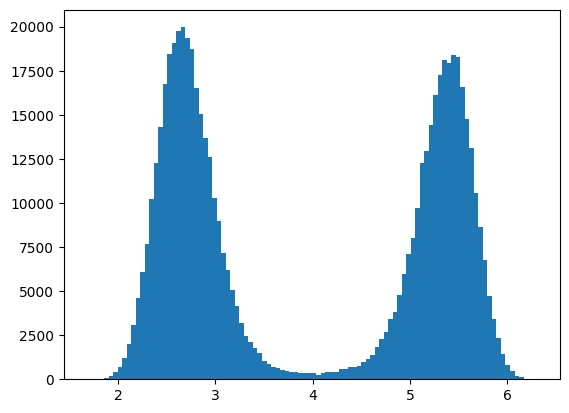

In [4]:
# first define system dimensionality and a target energy/distribution

dim = 8
n_particles = 4
n_dimensions = dim // n_particles

# DW parameters
a=0.9
b=-4
c=0
offset=4

target = MultiDoubleWellPotential(dim, n_particles, a, b, c, offset, two_event_dims=False)

# define a MCMC sampler to sample from the target energy

dw4_data = np.load("../data/dw4-dataidx.npy", allow_pickle=True)
all_data = remove_mean(dw4_data[0], n_particles, n_dimensions)
idx = dw4_data[1]
data = all_data[idx[:100000]]
val_data = all_data[idx[100000:500000]]
data_holdout = all_data[idx[-500000:]]
data_holdout.shape

dists_data = as_numpy(compute_distances(data, n_particles, n_dimensions))

plt.hist(dists_data.reshape(-1), bins=100);

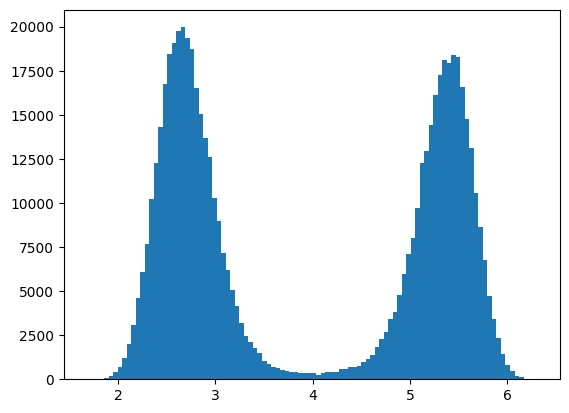

In [5]:
n_data = 100000
data_smaller = data[:n_data].clone()
data_smaller = data_smaller
data_smaller.shape

PATH = "models/DW4_equivariant_nODE-egnn-100000"
dists_data = as_numpy(compute_distances(data_smaller, n_particles, n_dimensions))

plt.hist(dists_data.reshape(-1), bins=100);

In [6]:
from tbg.utils import remove_mean as tbg_remove_mean

class EGNN_dynamics_consistency(nn.Module):
    def __init__(
        self,
        n_particles,
        n_dimension,
        hidden_nf=64,
        device="cpu",
        act_fn=torch.nn.SiLU(),
        n_layers=4,
        recurrent=True,
        attention=False,
        condition_time=True,
        tanh=False,
        mode="egnn_dynamics",
        agg="sum",
    ):
        super().__init__()
        self.mode = mode
        if mode == "egnn_dynamics":
            self.egnn = EGNN(
                in_node_nf=2,
                in_edge_nf=1,
                hidden_nf=hidden_nf,
                device=device,
                act_fn=act_fn,
                n_layers=n_layers,
                recurrent=recurrent,
                attention=attention,
                tanh=tanh,
                agg=agg,
            )

        self.device = device
        self._n_particles = n_particles
        self._n_dimension = n_dimension
        self.edges = self._create_edges()
        self._edges_dict = {}
        self.condition_time = condition_time
        # Count function calls
        self.counter = 0

    def forward(self, t, xs, d=None):

        n_batch = xs.shape[0]
        edges = self._cast_edges2batch(self.edges, n_batch, self._n_particles)
        edges = [edges[0], edges[1]]
        x = xs.reshape(n_batch * self._n_particles, self._n_dimension).clone()
        h = torch.ones(n_batch, self._n_particles, 2).to(self.device)
        t = torch.tensor(t).to(xs)
        if t.shape != (n_batch, 1):
            t = t.repeat(n_batch)
        t = t.reshape(n_batch, 1)
        if d is None:
            d = torch.zeros_like(t)

        td = torch.cat([t, d], dim=-1)
        if self.condition_time:
            h = h * td.unsqueeze(1)
        h = h.reshape(n_batch * self._n_particles, 2)
        if self.mode == "egnn_dynamics":
            edge_attr = torch.sum((x[edges[0]] - x[edges[1]]) ** 2, dim=1, keepdim=True)
            _, x_final = self.egnn(h, x, edges, edge_attr=edge_attr)
            vel = x_final - x

        elif self.mode == "gnn_dynamics":
            h = torch.cat([h, x], dim=1)
            vel = self.gnn(h, edges)

        vel = vel.view(n_batch, self._n_particles, self._n_dimension)
        vel = tbg_remove_mean(vel)
        self.counter += 1
        return vel.view(n_batch, self._n_particles * self._n_dimension)

    def _create_edges(self):
        rows, cols = [], []
        for i in range(self._n_particles):
            for j in range(i + 1, self._n_particles):
                rows.append(i)
                cols.append(j)
                rows.append(j)
                cols.append(i)
        return [torch.LongTensor(rows), torch.LongTensor(cols)]

    def _cast_edges2batch(self, edges, n_batch, n_nodes):
        if n_batch not in self._edges_dict:
            self._edges_dict = {}
            rows, cols = edges
            rows_total, cols_total = [], []
            for i in range(n_batch):
                rows_total.append(rows + i * n_nodes)
                cols_total.append(cols + i * n_nodes)
            rows_total = torch.cat(rows_total).to(self.device)
            cols_total = torch.cat(cols_total).to(self.device)

            self._edges_dict[n_batch] = [rows_total, cols_total]
        return self._edges_dict[n_batch]    

In [7]:
import torch
from zuko.distributions import DiagNormal
from zuko.flows.autoregressive import MaskedAutoregressiveTransform
from zuko.lazy import Flow, UnconditionalDistribution
from zuko.transforms import (CircularShiftTransform, ComposedTransform,
                             MonotonicRQSTransform)

class OurMAF(Flow):
    def __init__(
        self,
        features: int,
        context: int = 0,
        transforms: int = 3,
        randperm: bool = False,
        base=None,
        **kwargs,
    ):
        orders = [
            torch.arange(features),
            torch.flipud(torch.arange(features)),
        ]

        transforms = [
            MaskedAutoregressiveTransform(
                features=features,
                context=context,
                order=torch.randperm(features) if randperm else orders[i % 2],
                **kwargs,
            )
            for i in range(transforms)
        ]
        if base is None:
            base = UnconditionalDistribution(
                DiagNormal,
                torch.zeros(features),
                torch.ones(features),
                buffer=True,
            )
        super().__init__(transforms, base)


class OurNSF(OurMAF):
    def __init__(
        self,
        features: int,
        context: int = 0,
        bins: int = 8,
        base=None,
        **kwargs,
    ):
        if base is None:
            base = UnconditionalDistribution(
                MyMeanFreeNormalDistribution,
                8,
                4,
                buffer=True,
            )

        super().__init__(
            features=features,
            context=context,
            univariate=MonotonicRQSTransform,
            shapes=[(bins,), (bins,), (bins - 1,)],
            base=base,
            **kwargs,
        )

# # now set up a prior
# prior =  MeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()


class MyMeanFreeNormalDistribution(torch.distributions.MultivariateNormal):
    """Mean-free normal distribution."""

    def __init__(self, dim, n_particles, std=1.0):
        loc = torch.zeros(dim)
        scale_tril = torch.eye(dim)
        super().__init__(loc=loc, scale_tril=scale_tril)
        self._dim = dim
        self._n_particles = n_particles
        self._spacial_dims = dim // n_particles
        self._std = std

    def log_prob(self, x):
        x = x.view(-1, self._n_particles, self._spacial_dims)
        x = self._remove_mean(x).view(-1, self._dim)
        return (-0.5 * x.pow(2).sum(dim=-1, keepdim=True) / self._std**2).flatten()

    def rsample(self, n_samples, temperature=1.0):
        x = torch.ones(
            (n_samples, self._n_particles, self._spacial_dims),
        ).normal_(mean=0, std=self._std)
        x = self._remove_mean(x)
        x = x.reshape(n_samples, self._dim).cuda()
        return x

    def _remove_mean(self, x):
        x = x.view(-1, self._n_particles, self._spacial_dims)
        return x - torch.mean(x, dim=1, keepdim=True)

# now set up a prior
class MyMeanFreeNormalDistributionCopy(Energy, Sampler):
    """ Mean-free normal distribution. """

    def __init__(self, dim, n_particles, std=1., two_event_dims=True):
        if two_event_dims:
            super().__init__([n_particles, dim // n_particles])
        else:
            super().__init__(dim)
        self._two_event_dims = two_event_dims
        self._dim = dim
        self._n_particles = n_particles
        self._spacial_dims = dim // n_particles
        self.register_buffer("_std", torch.as_tensor(std))

    def forward(self, n_samples, temperature=1.):
        samples = self.sample(n_samples, temperature)
        energy = 0.5 * samples.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2
        return samples, energy.squeeze()
        
    def _energy(self, x):
        x = self._remove_mean(x).view(-1, self._dim)
        # TODO: make consistent
        return 0.5 * x.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2

    def sample(self, n_samples, temperature=1.):
        x = torch.ones((n_samples, self._n_particles, self._spacial_dims), dtype=self._std.dtype,
                         device=self._std.device).normal_(mean=0, std=self._std)
        x = self._remove_mean(x)
        if not self._two_event_dims:
            x = x.view(-1, self._dim)
        return x

    def _remove_mean(self, x):
        x = x.view(-1, self._n_particles, self._spacial_dims)
        x = x - torch.mean(x, dim=1, keepdim=True)
        return x

prior =  MyMeanFreeNormalDistributionCopy(dim, n_particles, two_event_dims=False).cuda()

In [8]:
import math

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

img_size = 8
channel_size = 1

# we use a small model for fast demonstration, increase the model size for better results
patch_size = 1
channels = 128
blocks = 8
layers_per_block = 4
# try different noise levels to see its effect
noise_std = 0.1
n_epochs=100
dim = 8


class CosineLRSchedule(torch.nn.Module):
    counter: torch.Tensor

    def __init__(self, optimizer, warmup_steps: int, total_steps: int, min_lr: float, max_lr: float):
        super().__init__()
        self.register_buffer('counter', torch.zeros(()))
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.optimizer = optimizer
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.set_lr(min_lr)

    def set_lr(self, lr: float) -> float:
        if self.min_lr <= lr <= self.max_lr:
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr
        return max(self.min_lr, min(self.max_lr, lr))

    def step(self) -> float:
        with torch.no_grad():
            counter = self.counter.add_(1).item()
        if self.counter <= self.warmup_steps:
            new_lr = self.min_lr + counter / self.warmup_steps * (self.max_lr - self.min_lr)
            return self.set_lr(new_lr)

        t = (counter - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        new_lr = self.min_lr + 0.5 * (1 + math.cos(math.pi * t)) * (self.max_lr - self.min_lr)
        return self.set_lr(new_lr)


net_dynamics = EGNN_dynamics_consistency(n_particles=n_particles, device='cuda',  n_dimension=dim // n_particles, hidden_nf=256,
    act_fn=torch.nn.SiLU(), n_layers=5, recurrent=True, tanh=True, attention=True, condition_time=True, mode='egnn_dynamics', agg='sum')


In [9]:
# Initialize divergence estimators
brute_force_estimator = BruteForceEstimator()

bb_dynamics = BlackBoxDynamics(
    dynamics_function=net_dynamics,
    divergence_estimator=brute_force_estimator
)

flow = DiffEqFlow(
    dynamics=bb_dynamics
)

# having a flow and a prior, we can now define a Boltzmann Generator

bg = BoltzmannGenerator(prior, flow, target).cuda()

# use DTO in the training process
flow._use_checkpoints = True

# Anode options
options={
    "Nt": 20,
    "method": "RK4"
}
flow._kwargs = options

# train with convex mixture of NLL and KL loss

n_kl_samples = 512
n_batch = 512
batch_iter = IndexBatchIterator(len(data_smaller), n_batch)


nsf_flow = OurNSF(features=dim, transforms=12, hidden_features=(512, 512)).cuda()
optim = torch.optim.Adam(net_dynamics.parameters())
nsf_optimizer = torch.optim.Adam(nsf_flow.parameters())


n_epochs = 80
# lr_schedule_flow = CosineLRSchedule(optim, len(batch_iter), n_epochs * len(batch_iter), 1e-6, 5e-4)
lr_schedule_nsf_flow = CosineLRSchedule(nsf_optimizer, len(batch_iter), n_epochs * len(batch_iter), 1e-6, 5e-4)

n_report_steps = 5

# mixing parameter

reporter = LossReporter("NLL", "Consistency")
val_losses = []

In [10]:
PATH = "models/DW4_shortcut_non_invertible_one_tarflow"
PATH_SHORTCUT = "models/DW4_shortcut_shortcut"
#torch.save(tarflow.state_dict(), PATH)
#tarflow.load_state_dict(torch.load(PATH))
#torch.save(net_dynamics.state_dict(), PATH_SHORTCUT)
net_dynamics.load_state_dict(torch.load(PATH_SHORTCUT))

/tmp/ipykernel_133770/2069789748.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_dynamics.load_state_dict(torch.load(PATH_SHORTCUT))


<All keys matched successfully>

In [11]:
class BruteForceEstimatorFast(torch.nn.Module):
    """
    Exact bruteforce estimation of the divergence of a dynamics function.
    """

    def __init__(self):
        super().__init__()

    def forward(self, dynamics, t, xs):
        """
        Computes the change of the system `dxs` due to a time independent dynamics function.
        Furthermore, also computes the exact change of log density
        which is equal to the divergence of the change `dxs`.

        Parameters
        ----------
        dynamics : torch.nn.Module
            A dynamics function that computes the change of the system and its density.
        t : PyTorch tensor
            The current time
        xs : PyTorch tensor
            The current configuration of the system

        Returns
        -------
        dxs, -divergence: PyTorch tensors
            The combined state update of shape `[n_batch, n_dimensions]`
            containing the state update of the system state `dx/dt`
            (`dxs`) and the negative update of the log density (`-divergence`)
        """

        with torch.set_grad_enabled(True):
            xs.requires_grad_(True)
            x = [xs[:, [i]] for i in range(xs.size(1))]

            dxs = dynamics(t, torch.cat(x, dim=1))

            assert len(dxs.shape) == 2, "`dxs` must have shape [n_btach, system_dim]"
            divergence = 0
            for i in range(xs.size(1)):
                divergence += torch.autograd.grad(dxs[:, [i]], x[i], torch.ones_like(dxs[:, [i]]), retain_graph=True)[0]

        return dxs, -divergence.view(-1, 1)
    
brute_force_estimator_fast = BruteForceEstimatorFast()
# use OTD in the evaluation process
bb_dynamics._divergence_estimator = brute_force_estimator_fast
bg.flow._integrator_atol = 1e-3
bg.flow._integrator_rtol = 1e-3
flow._use_checkpoints = False

## Sampling with dopri5

In [12]:
x0_samples = torch.load("x0_samples_dopri.pt")
dopri_samples = torch.load("dopri_samples_shortcut.pt")

/tmp/ipykernel_133770/432166525.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x0_samples = torch.load("x0_samples_dopri.pt")
/tmp/ipykernel_133770/432166525.py:2: Futu

In [13]:
sum(p.numel() for p in nsf_flow.parameters() if p.requires_grad)

4339872

In [14]:
import pdb
import os
from tqdm import tqdm

dopri_batch_iter = IndexBatchIterator(len(dopri_samples), n_batch)
tarflow_training = 'regression'
n_epochs = 100

def train_flow_regression():
    losses = []
    for epoch in tqdm(range(n_epochs)):
        for it, idxs in enumerate(dopri_batch_iter):
            x1 = dopri_samples[idxs].cuda()
            x0 = x0_samples[idxs].cuda()

            nsf_optimizer.zero_grad()
            x1_hat = nsf_flow.transform()(x0)
            nsf_flow_loss = torch.mean((x1_hat - x1) ** 2)

            losses.append(nsf_flow_loss)
    
            if not torch.isnan(nsf_flow_loss):
                nsf_flow_loss.backward()
                # torch.nn.utils.clip_grad_norm_(nsf_flow.parameters(), 1.0)
                # torch.nn.utils.clip_grad_value_(nsf_flow.parameters(), 1.0)
                nsf_optimizer.step()
                lr_schedule_nsf_flow.step()
                
            if it % n_report_steps == 0:
                print("\repoch: {0}, iter: {1}/{2}, nsf_flow_loss: {3:.4}".format(
                        epoch,
                        it,
                        len(dopri_batch_iter),
                        nsf_flow_loss.item()
                    ), end="")

    return nsf_flow, losses
        
model_path = "nsf_flow_v4.pt"
if not os.path.exists(model_path):
    nsf_flow, losses = train_flow_regression()
    plt.plot(torch.stack(losses).detach().cpu())
    torch.save(nsf_flow, model_path)
else:
    nsf_flow = torch.load(model_path)

/tmp/ipykernel_133770/1129711623.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nsf_flow = torch.load(model_path)


  0%|                                                                                                                                                                                                                        | 0/100 [00:00<?, ?it/s]

epoch: 0, iter: 190/195, nsf_mle_flow_loss: -1.54644

  1%|██                                                                                                                                                                                                              | 1/100 [00:11<18:36, 11.27s/it]

epoch: 1, iter: 190/195, nsf_mle_flow_loss: -2.0116

  2%|████▏                                                                                                                                                                                                           | 2/100 [00:21<17:21, 10.63s/it]

...

epoch: 98, iter: 190/195, nsf_mle_flow_loss: -16.29

 99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 99/100 [17:11<00:10, 10.61s/it]

epoch: 99, iter: 190/195, nsf_mle_flow_loss: -15.54

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [17:21<00:00, 10.42s/it]

epoch: 99, iter: 195/195, nsf_mle_flow_loss: -15.81

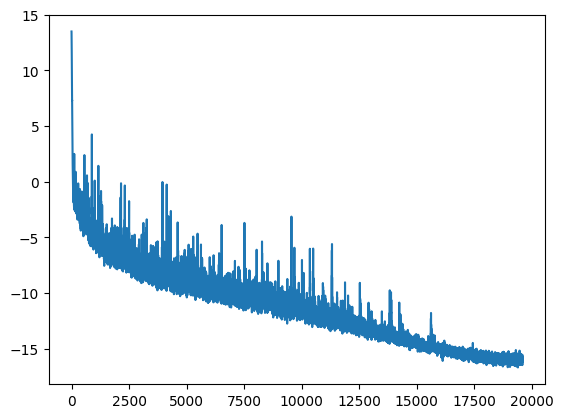

In [15]:
import pdb
import os

nsf_mle_flow = OurNSF(features=dim, transforms=12, hidden_features=(512, 512)).cuda()
nsf_mle_optimizer = torch.optim.Adam(nsf_mle_flow.parameters())
lr_schedule_nsf_mle_flow = CosineLRSchedule(nsf_mle_optimizer, len(batch_iter), n_epochs * len(batch_iter), 1e-6, 5e-4)

def train_flow_mle():
    mle_losses = []
    for epoch in tqdm(range(n_epochs)):
        for it, idxs in enumerate(batch_iter):
            x1 = data_smaller[idxs].cuda()

            nsf_mle_optimizer.zero_grad()
            nsf_mle_flow_loss = -nsf_mle_flow().log_prob(x1).mean()  
            mle_losses.append(nsf_mle_flow_loss)
    
            if not torch.isnan(nsf_mle_flow_loss):
                nsf_mle_flow_loss.backward()
                torch.nn.utils.clip_grad_norm_(nsf_mle_flow.parameters(), 1.0)
                torch.nn.utils.clip_grad_value_(nsf_mle_flow.parameters(), 1.0)
                nsf_mle_optimizer.step()
                lr_schedule_nsf_mle_flow.step()
                
            if it % n_report_steps == 0:
                print("\repoch: {0}, iter: {1}/{2}, nsf_mle_flow_loss: {3:.4}".format(
                        epoch,
                        it,
                        len(batch_iter),
                        nsf_mle_flow_loss.item()
                    ), end="")

    return nsf_mle_flow, mle_losses
        


model_path = "nsf_mle_v4.pt"
if not os.path.exists(model_path):
    nsf_flow, mle_losses = train_flow_mle()
    plt.plot(torch.stack(mle_losses).detach().cpu())
    torch.save(nsf_mle_flow, model_path)
else:
    nsf_mle_flow = torch.load(model_path)

In [16]:
x0_samples.shape

torch.Size([100000, 8])

# Sampling with shortcut models

## Including the likelihood

In [ ]:
from bgflow import BlackBoxDynamics, TimeIndependentDynamics, BruteForceEstimator, HutchinsonEstimator, DenseNet
from bgflow.utils.autograd import brute_force_jacobian_trace
import torch


class BruteForceEstimatorFastStep(torch.nn.Module):
    """
    Exact bruteforce estimation of the divergence of a dynamics function.
    """

    def __init__(self):
        super().__init__()

    def forward(self, dynamics, t, xs, s):
        """
        Computes the change of the system `dxs` due to a time independent dynamics function.
        Furthermore, also computes the exact change of log density
        which is equal to the divergence of the change `dxs`.

        Parameters
        ----------
        dynamics : torch.nn.Module
            A dynamics function that computes the change of the system and its density.
        t : PyTorch tensor
            The current time
        xs : PyTorch tensor
            The current configuration of the system
        s : PyTorch tensor
            The step size
        Returns
        -------
        dxs, -divergence: PyTorch tensors
            The combined state update of shape `[n_batch, n_dimensions]`
            containing the state update of the system state `dx/dt`
            (`dxs`) and the negative update of the log density (`-divergence`)
        """

        with torch.set_grad_enabled(True):
            xs.requires_grad_(True)
            x = [xs[:, [i]] for i in range(xs.size(1))]

            dxs = dynamics(t, torch.cat(x, dim=1), s)

            assert len(dxs.shape) == 2, "`dxs` must have shape [n_btach, system_dim]"
            divergence = 0
            for i in range(xs.size(1)):
                divergence += torch.autograd.grad(dxs[:, [i]], x[i], torch.ones_like(dxs[:, [i]]), retain_graph=True)[0]

        return dxs, divergence.view(-1, 1)
    
brute_force_estimator_fast_step = BruteForceEstimatorFastStep()


In [ ]:
def euler_solve_with_logp(model, divergence, x0, s, use_shortcut=True):
    """
    model:   nn.Module that computes v(x, t).
    x0:      (batch_size, dim) initial samples.
    logp0:   (batch_size,) initial log p(x0).
    T:       final time.
    N:       number of Euler steps.

    Returns:
        xN:    (batch_size, dim) final samples at t=T.
        logpN: (batch_size,) log probability of xN.
    """
    N = int(1/s)
    x = x0
    t = torch.zeros(x0.shape[0],1).to(x)
    dt = torch.ones(x0.shape[0],1).to(x) * s
    logp = torch.zeros(x0.shape[0],1).to(x)
    for _ in range(N):
        # Make sure x is differentiable so we can compute div
        x.requires_grad_(True)
        # 2. Compute velocity and divergence
        v, div_v = divergence(model, t, x, dt if use_shortcut else None)

        # 3. Euler update for x
        x_next = x + dt * v

        # 4. Euler update for log p
        # d/dt [log p] = - div(v), so forward Euler => logp_next = logp - dt * div_v
        logp_next = logp - dt * div_v

        # Detach x_next & logp_next to avoid building huge graphs
        x = x_next.detach()
        logp = logp_next.detach()

        # Increase time
        t = t + dt
    return x, logp


/tmp/ipykernel_133770/3025110601.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nsf_mle_flow = torch.load(model_path)
100%|█████████████████████████████████████████████

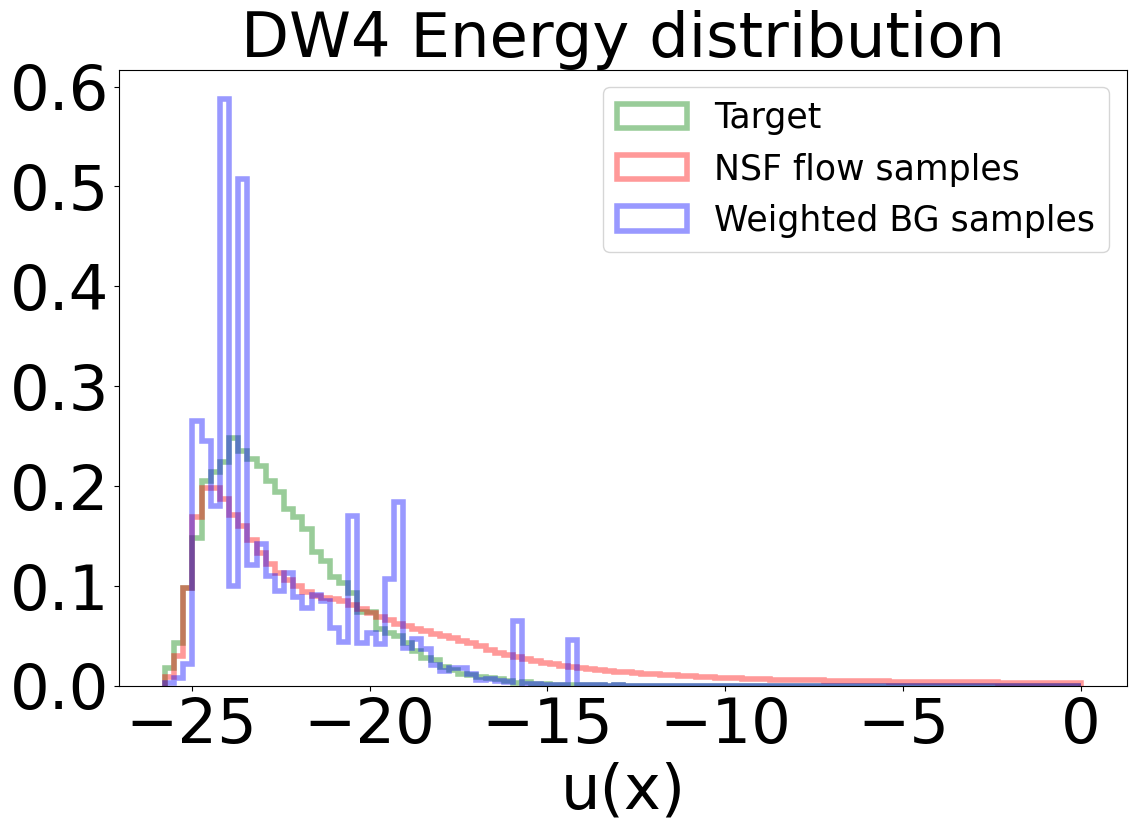

In [19]:
from tqdm import tqdm
n_samples = 10_000
x0_list, x1_list, log_probs_list = [], [], []

nsf_mle_flow = torch.load(model_path)
for i in tqdm(range(300)):
    with torch.no_grad():
        x0 = nsf_mle_flow.base().sample(n_samples)
        # x1 = nsf_flow.transform().inv(x0)
        x1 = nsf_flow().sample(n_samples)
        log_probs = nsf_mle_flow().log_prob(x1) 
        x0_list.append(x0)
        x1_list.append(x1)
        log_probs_list.append(log_probs)


x0 = torch.cat(x0_list)
x1 = torch.cat(x1_list)
log_probs = torch.cat(log_probs_list)

energies_data = target.energy(data).detach().cpu().numpy()
energies_bg = target.energy(data_smaller).detach().cpu().numpy().flatten()
energies_flow = target.energy(x1).detach().cpu().numpy().flatten()
log_weights = -energies_flow - log_probs.detach().cpu().numpy()
log_w_np = as_numpy(log_weights)
energies_prior = target.energy(data).detach().cpu().numpy()
min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"NSF flow samples");
plt.hist(energies_flow.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Weighted BG samples", weights=np.exp(log_w_np));
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [20]:
from bgflow.bg import sampling_efficiency
sampling_efficiency(torch.from_numpy(log_w_np)).item()

1.3006909284740686e-05

In [ ]:
from tqdm import tqdm
n_samples = 10_000
x0_list, x1_list, log_probs_list = [], [], []

for i in tqdm(range(300)):
    with torch.no_grad():
        x0 = nsf_flow.base().sample(n_samples)
        # x0 = prior.sample(n_samples).cuda()
        x1 = nsf_flow.transform()(x0)
        log_probs = nsf_flow().log_prob(x1) 
        #log_probs = -1 * (prior.energy(z).squeeze() - logdets)
        #log_probs[torch.isnan(log_probs)] = 1.0
        x0_list.append(x0)
        x1_list.append(x1)
        log_probs_list.append(log_probs)

x0 = torch.cat(x0_list)
x1 = torch.cat(x1_list)
log_probs = torch.cat(log_probs_list)
print(log_probs.shape)
energies_data = target.energy(data).detach().cpu().numpy()
#energies_bg = target.energy(x1).detach().cpu().numpy().flatten()
energies_bg = target.energy(data_smaller).detach().cpu().numpy().flatten()
energies_flow = target.energy(x1).detach().cpu().numpy().flatten()
print(energies_bg.shape)
log_weights = -energies_flow - log_probs.detach().cpu().numpy()
log_w_np = as_numpy(log_weights)
print(log_weights)
energies_prior = target.energy(data).detach().cpu().numpy()
print(np.exp(log_w_np).shape)
min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
# plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
#          color="r", label=f"BG samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"NSF flow samples");
plt.hist(energies_flow.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Weighted BG samples", weights=np.exp(log_w_np));
#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [25]:
#x0_prime = tarflow.reverse(x1)
def kish_effective_sample_size(weights: torch.Tensor) -> torch.Tensor:
    """
    Computes the Kish effective sample size (ESS) for a set of weights.
    
    Args:
        weights (torch.Tensor): A 1D tensor of sample weights.
        
    Returns:
        torch.Tensor: The effective sample size (scalar).
    """
    # Sum of weights
    sum_w = torch.sum(weights)
    # Sum of squared weights
    sum_w_sq = torch.sum(weights ** 2)
    # Kish formula for ESS
    ess = sum_w.pow(2) / sum_w_sq
    return ess

In [32]:
from scipy.stats import qmc
eps = 0.5
num_timesteps = 100

def nsf_mle_prior_energy(x): 
    return nsf_mle_flow().log_prob(x)

def nsf_regression_prior_energy(x): 
    return nsf_flow().log_prob(x)
    
target_energy = lambda x: target.energy(x).flatten()

def linear_energy_interpolation(x, t):
    return ((1 - t) * nsf_mle_prior_energy(x) + t * target_energy(x)).squeeze()

energy_grad_x_fn = torch.compile(torch.vmap(torch.func.grad(linear_energy_interpolation), in_dims=(0, None)))
energy_partial_t_fn = torch.compile(torch.vmap(torch.func.grad(linear_energy_interpolation, argnums=1), in_dims=(0, None)))

X_0 = x1[:10000]
X = X_0
initial_prior = nsf_mle_prior_energy(X)
A = torch.zeros(X.shape[0]).cuda() #
timesteps = torch.linspace(0, 1, num_timesteps + 1)
dt = 1 / num_timesteps
A_list = [A]
ESS_list = []
sampler = qmc.Halton(d=1, scramble=True)
ess_trigger = 0
with torch.no_grad():

    for t in tqdm(timesteps[:-1]):
    
        dX_t = - eps * energy_grad_x_fn(X, t) * dt + math.sqrt(2 * eps * dt) * torch.randn_like(X)
        dA_t = - energy_partial_t_fn(X, t).cuda() * dt
    
        X = X + dX_t
        A = A + dA_t
        A_list.append(A)
        ESS = kish_effective_sample_size(torch.softmax(A, dim=-1)).item() / len(A)
        ESS_list.append(ESS)
        
        if ESS < 0.8:
            ess_trigger += 1
            indexes = torch.multinomial(torch.softmax(A, dim=-1), len(A), replacement=True)
            X = X[indexes]
            A = torch.zeros_like(A)

    print("ESS Resampling triggered %d" % (ess_trigger) )
    jarzynski_samples = X
    jarzynski_weights = torch.softmax(A, dim=-1)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.66it/s]

ESS Resampling triggered 13


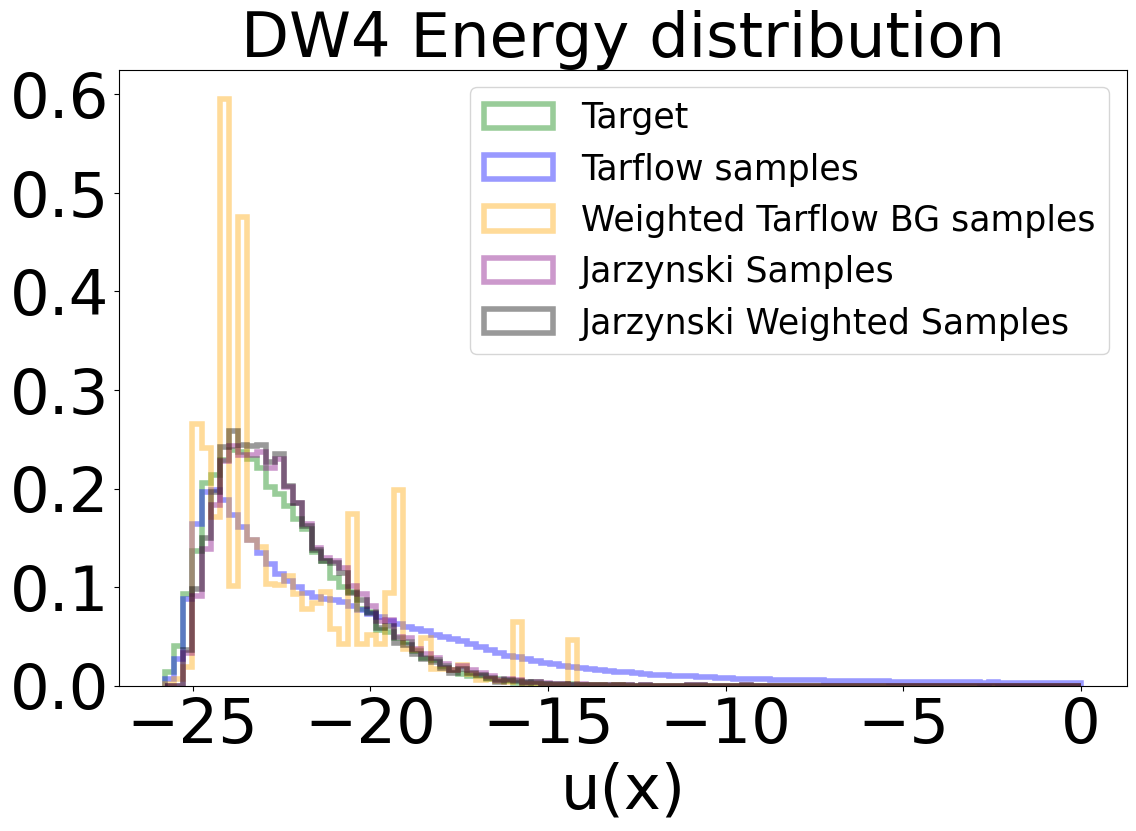

In [30]:

energies_jarzynski = target.energy(jarzynski_samples).detach().cpu().numpy().flatten()
energies_data = target.energy(data).detach().cpu().numpy().flatten()
#energies_bg = target.energy(x1).detach().cpu().numpy().flatten()
energies_bg = target.energy(dopri_samples).detach().cpu().numpy().flatten()
energies_flow = target.energy(x1).detach().cpu().numpy().flatten()
log_weights = - energies_flow - log_probs.detach().cpu().numpy()

log_jarzynski_weights = -(jarzynski_weights).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min())
max_energy = max(energies_data.max(), energies_bg.max())

plt.figure(figsize=(13,8))
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
#plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
#         color="r", label=f"Dopri5 samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Tarflow samples");
plt.hist(energies_flow, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="orange", label=f"Weighted Tarflow BG samples", weights=torch.softmax(torch.from_numpy(log_weights), dim=0))
plt.hist(energies_jarzynski, bins=100, density=True,  
         range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="purple", label=f"Jarzynski Samples")
plt.hist(energies_jarzynski, bins=100, density=True,  
         range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="black", label=f"Jarzynski Weighted Samples", weights=jarzynski_weights.detach().cpu().numpy())

#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);